In [1]:
# %matplotlib ipympl
from nrem_analysis.constant import PROCESSED_DIR, INTERIM_DIR, MOUSE_IDS_DUAL, FIGURES_DIR

import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
import cmap

import scipy.ndimage
import seaborn as sns

cyclic_cmap = cmap.Colormap('cmocean:phase').to_mpl()

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 320,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})

up_color = "#D55E00"
threshold_color = "#C44E52"

def detect_upstates(
    spikes: nap.TsGroup,
    bin_size = 0.01,
    percentile = 80,
    merge_thr = 0.1,
    short_thr = 0.04,
    long_thr = 2,
    time_units='s'
    ) -> nap.IntervalSet:
    x = spikes.count(bin_size=bin_size, time_units=time_units).sum(axis=1)
    x = x / bin_size
    x = x.smooth(std=2 * bin_size, time_units=time_units)
    thr = np.percentile(x, q=percentile)

    up_states = x.threshold(thr, method='above').time_support
    up_states = up_states.merge_close_intervals(threshold=merge_thr, time_units=time_units)
    up_states = up_states.drop_short_intervals(threshold=short_thr, time_units=time_units)
    up_states = up_states.drop_long_intervals(threshold=long_thr, time_units=time_units)
    return up_states, thr

In [2]:
mouse_id        = "107b"
data_dir        = INTERIM_DIR / mouse_id

sleep           = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sleep.npz")
turn_units      = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
head_direction  = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "head_direction.npz")
hd_units        = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "hd_units.npz")
virtual_hds     = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "virtual_hd.npz")
session         = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "session.npz")

nrem            = sleep[sleep['state'] == 'nrem'].intersect(session[session['state'] == 'homecage'])

# compute HD preferred angle
tcs = nap.compute_tuning_curves(hd_units, head_direction, bins=24, fs=1000, feature_names=['hd'])
tcs.values = scipy.ndimage.gaussian_filter1d(tcs.values, sigma=1, axis=1, mode="wrap")
pref_angle = tcs.idxmax(dim='hd').to_numpy().squeeze()

# order unit ids
order = np.argsort(pref_angle)
hd_uids = np.array(hd_units.keys())[order]

order = np.argsort(turn_units['turn_index'].values)
turn_uids = np.array(turn_units.keys())[order]

# detect up states
spikes = hd_units.restrict(nrem)
up_states, thr = detect_upstates(spikes)

In [3]:
ep = nrem[52]
print(ep)

hd_spikes = hd_units.restrict(ep)
turn_spikes = turn_units.restrict(ep)
up_eps = up_states.intersect(ep)
vhd = virtual_hds.restrict(ep)

# Turn units population vector
turn_pv = turn_spikes.count(bin_size=0.001).sum(axis=1) / 0.001
turn_pv = turn_pv.smooth(std=0.05)

# HD units population vector
hd_pv = hd_spikes.count(bin_size=0.01).sum(axis=1) / 0.01 
hd_pv = hd_pv.smooth(std=0.02)

t0, t1 = 23146, 23156

  index    start    end
      0    23119  23190
shape: (1, 2), time unit: sec.


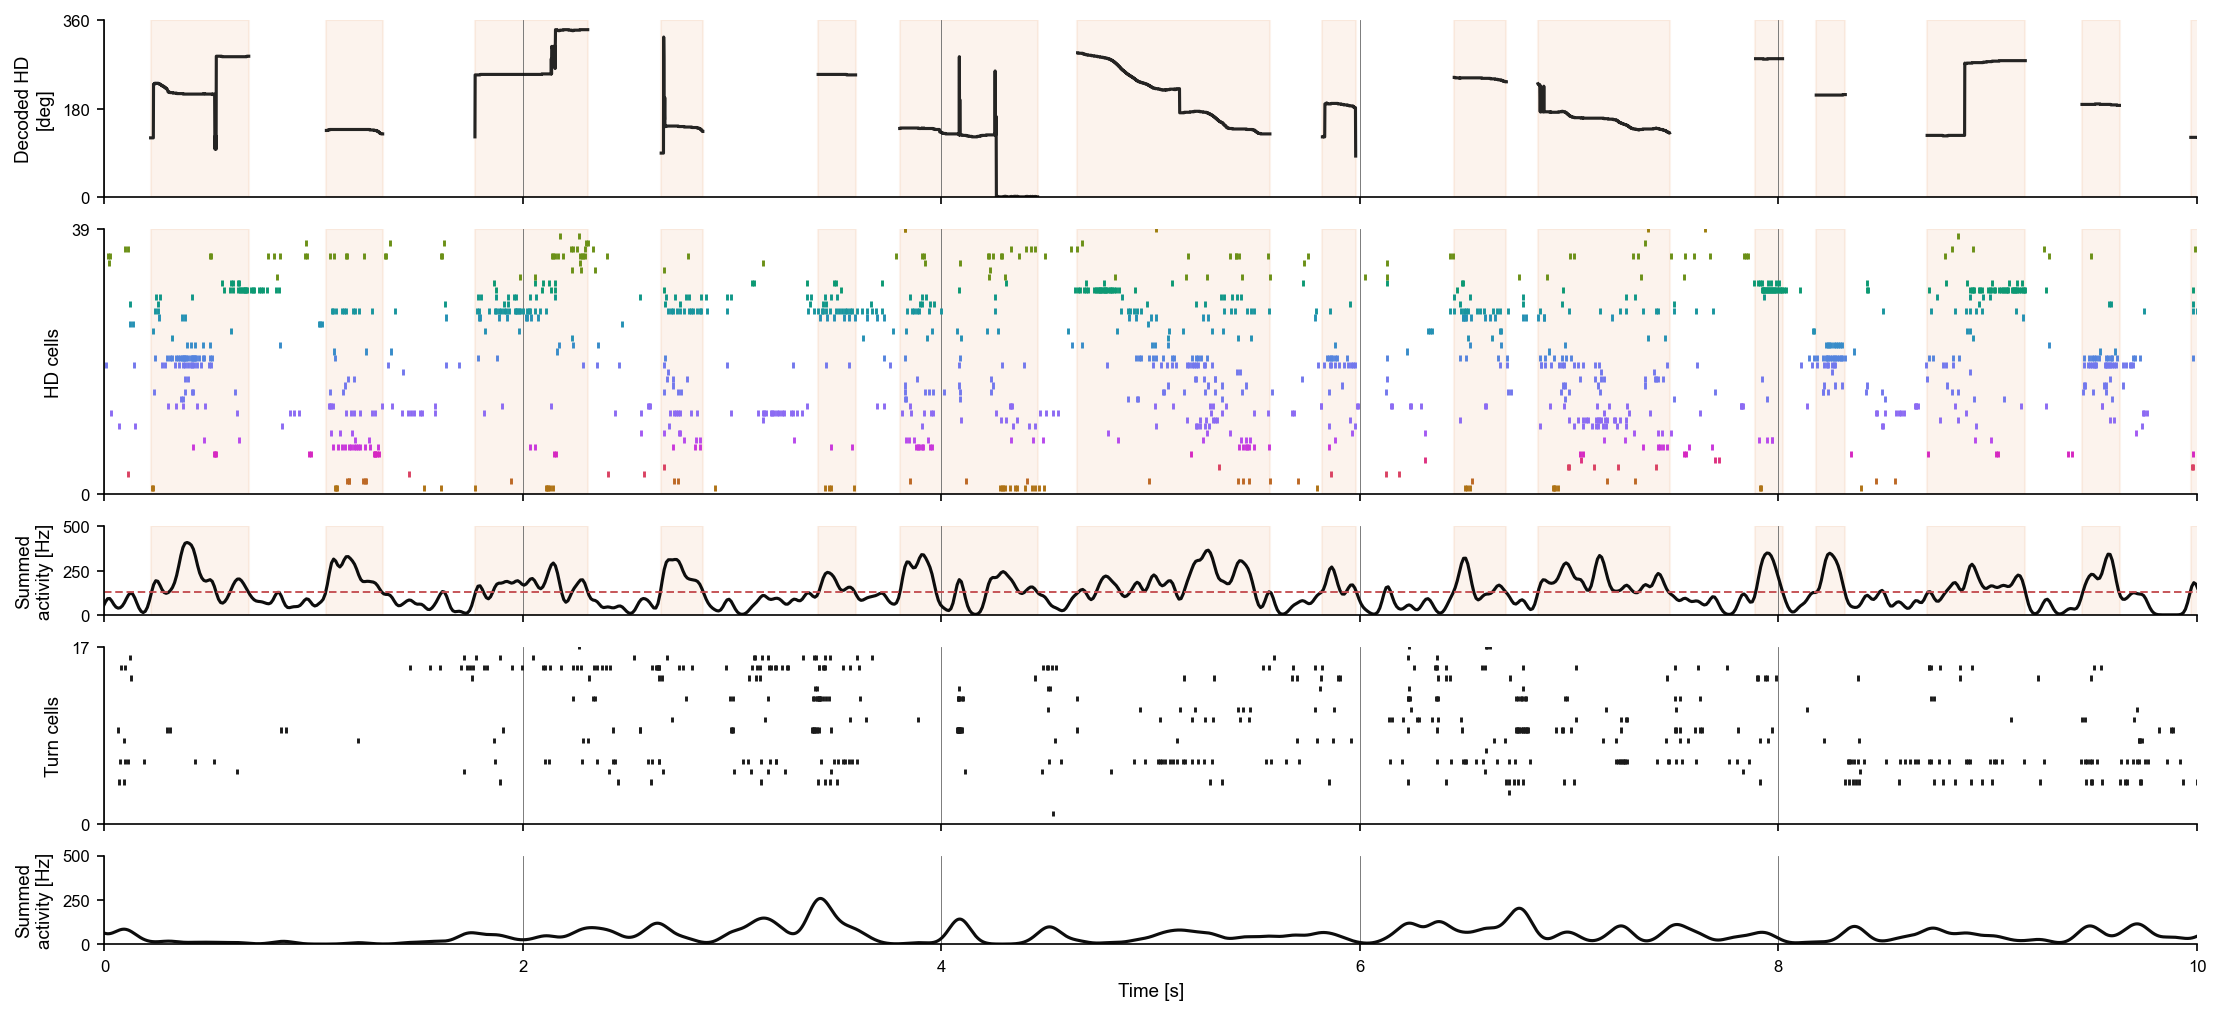

In [7]:
from matplotlib.ticker import FuncFormatter

f, ax = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(18, 8),
    sharex=True,
    gridspec_kw={'height_ratios': [2, 3, 1, 2, 1]})

# Decoded HD
for ep in up_eps:
    ax[0].plot(vhd.restrict(ep), color='0.05', alpha=0.9, linewidth=1.5)

# Up states
for a in ax[:3]:
    for start, end in up_eps.values:
        a.axvspan(
            start, end,
            color=up_color,
            alpha=0.07,
            zorder=0,
            )

# HD cells raster
for row, uid in enumerate(hd_uids, start=1):
    ax[1].eventplot(
        hd_spikes[uid].index,
        lineoffsets=row,
        linelengths=0.9,
        linewidths=1.4,
        colors=[cyclic_cmap(pref_angle[uid].item() / 360)],
        alpha=1,
    )

# HD cells population
ax[2].plot(hd_pv, linewidth=1.5, color='0.05')
ax[2].axhline(
    thr,
    color=threshold_color,
    linestyle=(0, (4, 2)),
    linewidth=0.9,
    )

# Turn cells raster
for row, uid in enumerate(turn_uids, start=1):
    ax[3].eventplot(
        turn_spikes[uid].index,
        lineoffsets=row,
        linelengths=0.5,
        linewidths=1.4,
        colors="0.10",
        alpha=1,
    )

# Population activity
ax[4].plot(turn_pv, color="0.05", linewidth=1.5)
# ax[4].axhline(
#     turn_pv.mean() + turn_pv.std(),
#     color=threshold_color,
#     linestyle=(0, (4, 2)),
#     linewidth=0.9,
# )

for a in ax:
    a.set_axisbelow(True)
    a.grid(axis='x', which='major', color='0.4', linewidth=0.4)
    a.spines[["top", "right"]].set_visible(False)

ax[0].set_ylabel("Decoded HD\n[deg]")
ax[0].set_ylim((0, 360))
ax[0].set_yticks([0, 180, 360])

ax[1].set_ylabel("HD cells")
ax[1].set_ylim(0, len(hd_uids))
ax[1].set_yticks([0, len(hd_uids)])

ax[2].set_ylabel("Summed\nactivity [Hz]")
# ax[2].set_yticks([0, 200, 400])
ax[2].set_ylim((0, 500))

ax[3].set_ylabel("Turn cells")
ax[3].set_ylim(0, len(turn_uids))
ax[3].set_yticks([0, len(turn_uids)])

ax[4].set_ylabel("Summed\nactivity [Hz]")
ax[4].set_xlabel("Time [s]")
ax[4].set_ylim((0, 500))
# ax[4].set_yticks([0, 200, 400])

ax[0].set_xlim((t0, t1))

# Display absolute time as time relative to t0
ax[-1].xaxis.set_major_formatter(
    FuncFormatter(lambda time, _: f"{time - t0:g}")
)

plt.savefig(FIGURES_DIR / "snapshots" / "nrem_upstates01.svg", format='svg', bbox_inches='tight')
plt.savefig(FIGURES_DIR / "snapshots" / "nrem_upstates01.png", format='png', bbox_inches='tight')
plt.show()

In [3]:
durations = []

for mouse_id in MOUSE_IDS_DUAL:
    sleep           = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sleep.npz")
    session         = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "session.npz")

    try:
        hd_units        = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "hd_units.npz")
    except FileNotFoundError:
        continue

    nrem            = sleep[sleep['state'] == 'nrem'].intersect(session[session['state'] == 'homecage'])
    spikes = hd_units.restrict(nrem)
    up_states, thr = detect_upstates(spikes)

    durations.append(np.diff(up_states.values))

durations = np.concatenate(durations)

Text(0.5, 0.98, 'Upstates duration (n=134456)')

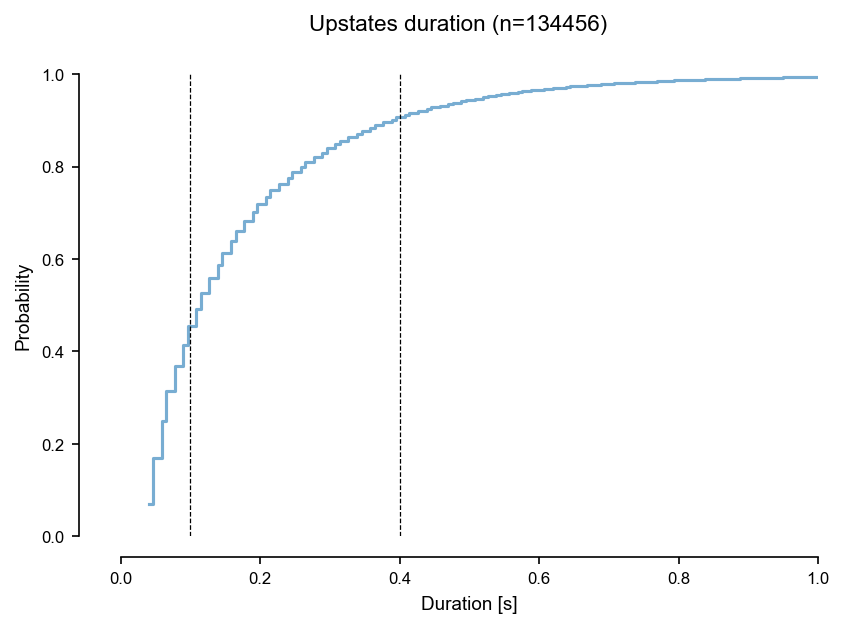

In [48]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.histplot(
    data=durations,
    # bins=100,
    element='step',
    stat='probability',
    fill=False,
    alpha=0.6,
    legend=False,
    ax=ax,
    cumulative=True,
    )

sns.despine()

ax.set_xlabel("Duration [s]")
ax.axvline(0.4, color='k', linestyle='--', linewidth=0.6)
ax.axvline(0.1, color='k', linestyle='--', linewidth=0.6)

ax.spines['left'].set_position(('outward', 20))
ax.spines['bottom'].set_position(('outward', 10))

ax.set_ylim(0, 1)
ax.set_xlim(0, 1)

fig.suptitle(f"Upstates duration (n={len(durations)})")
# plt.savefig(FIGURES_DIR / "sweeps_durations.svg", format='svg', bbox_inches='tight')
# plt.savefig(FIGURES_DIR / "sweeps_durations.png", format='png', bbox_inches='tight')

In [32]:
np.median(durations)

np.float64(0.11999999999534339)